In [60]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/spectra/'

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [3]:
ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

In [16]:
def psd_for_plot(data_array):
    # --- time spacing in seconds ---
    dt = (data_array.time[1] - data_array.time[0]).values / np.timedelta64(1, 's')
    fs = 1.0 / dt                     # sampling frequency (Hz)
    N = len(data_array)

    fft_values = np.fft.rfft(data_array - data_array.mean(dim='time'),axis=0)
    psd_hz = (np.abs(fft_values) ** 2) / (N * fs) # power from fft
    psd_hz[1:-1] *= 2 # variance preserving spectra
    psd_cpd = psd_hz / 86400

    freq_hz = np.fft.rfftfreq(N, d=dt)
    freq_cpd = freq_hz * 86400        # cycles per day
    
    return fft_values, psd_hz, psd_cpd, freq_hz, freq_cpd

In [69]:
vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)

In [70]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatter

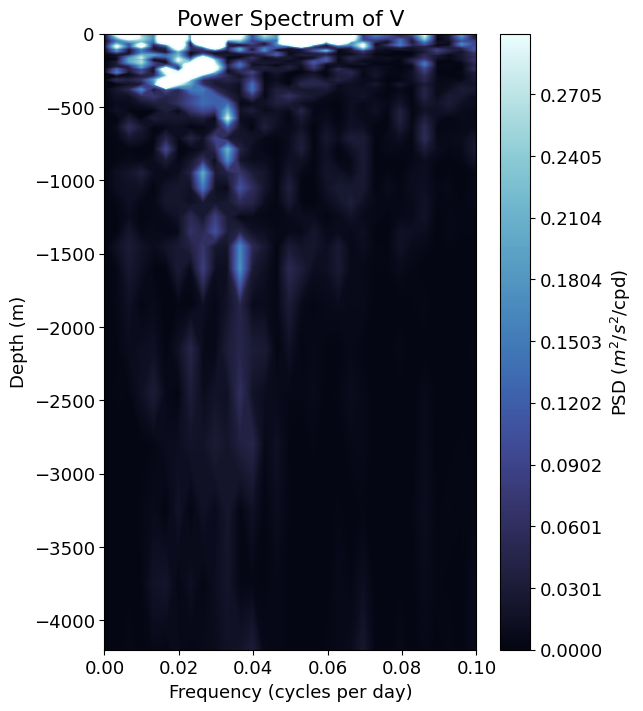

In [71]:
fig, ax = plt.subplots(figsize=(6,8))

psd_plot = np.where(psd > 1e-10, psd, np.nan)
levels = np.linspace(0,0.3,500)
cf = ax.contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.3, cmap=cmo.ice)
ax.set_title('Power Spectrum of V')
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(-4200,0)
ax.set_xlim(0.0,0.1)

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('PSD ($m^2/s^2$/cpd)')
fig.savefig(foldername + 'V_spectrum_v_depth_linearcolor.png',dpi=300)

/tmp/ipykernel_3475307/2155705405.py:5: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, norm=LogNorm(vmin=1e-4,vmax=1e0), cmap=cmo.ice)


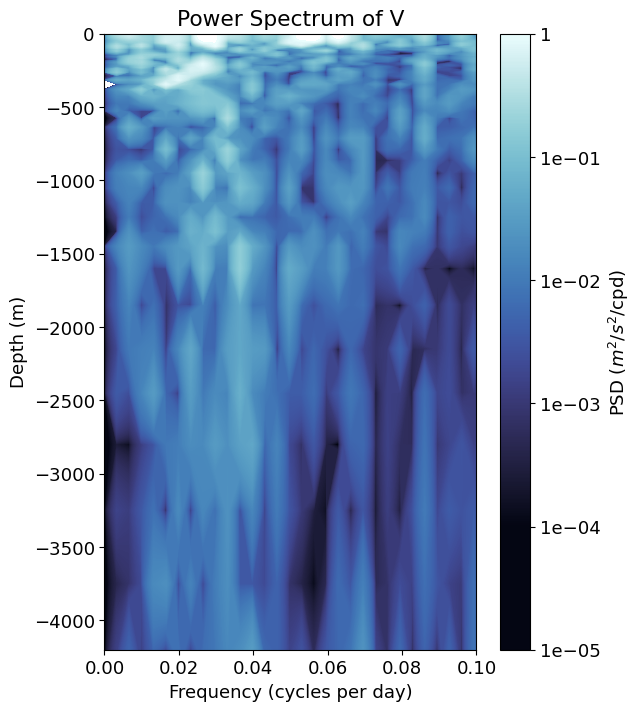

In [72]:
fig, ax = plt.subplots(figsize=(6,8))

psd_plot = np.where(psd > 1e-10, psd, np.nan)
levels = np.logspace(-5,0,500)
cf = ax.contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, norm=LogNorm(vmin=1e-4,vmax=1e0), cmap=cmo.ice)
ax.set_title('Power Spectrum of V')
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(-4200,0)
ax.set_xlim(0.0,0.1)

cbar = fig.colorbar(cf, ax=ax)
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('PSD ($m^2/s^2$/cpd)')
fig.savefig(foldername + 'V_spectrum_v_depth.png',dpi=300)

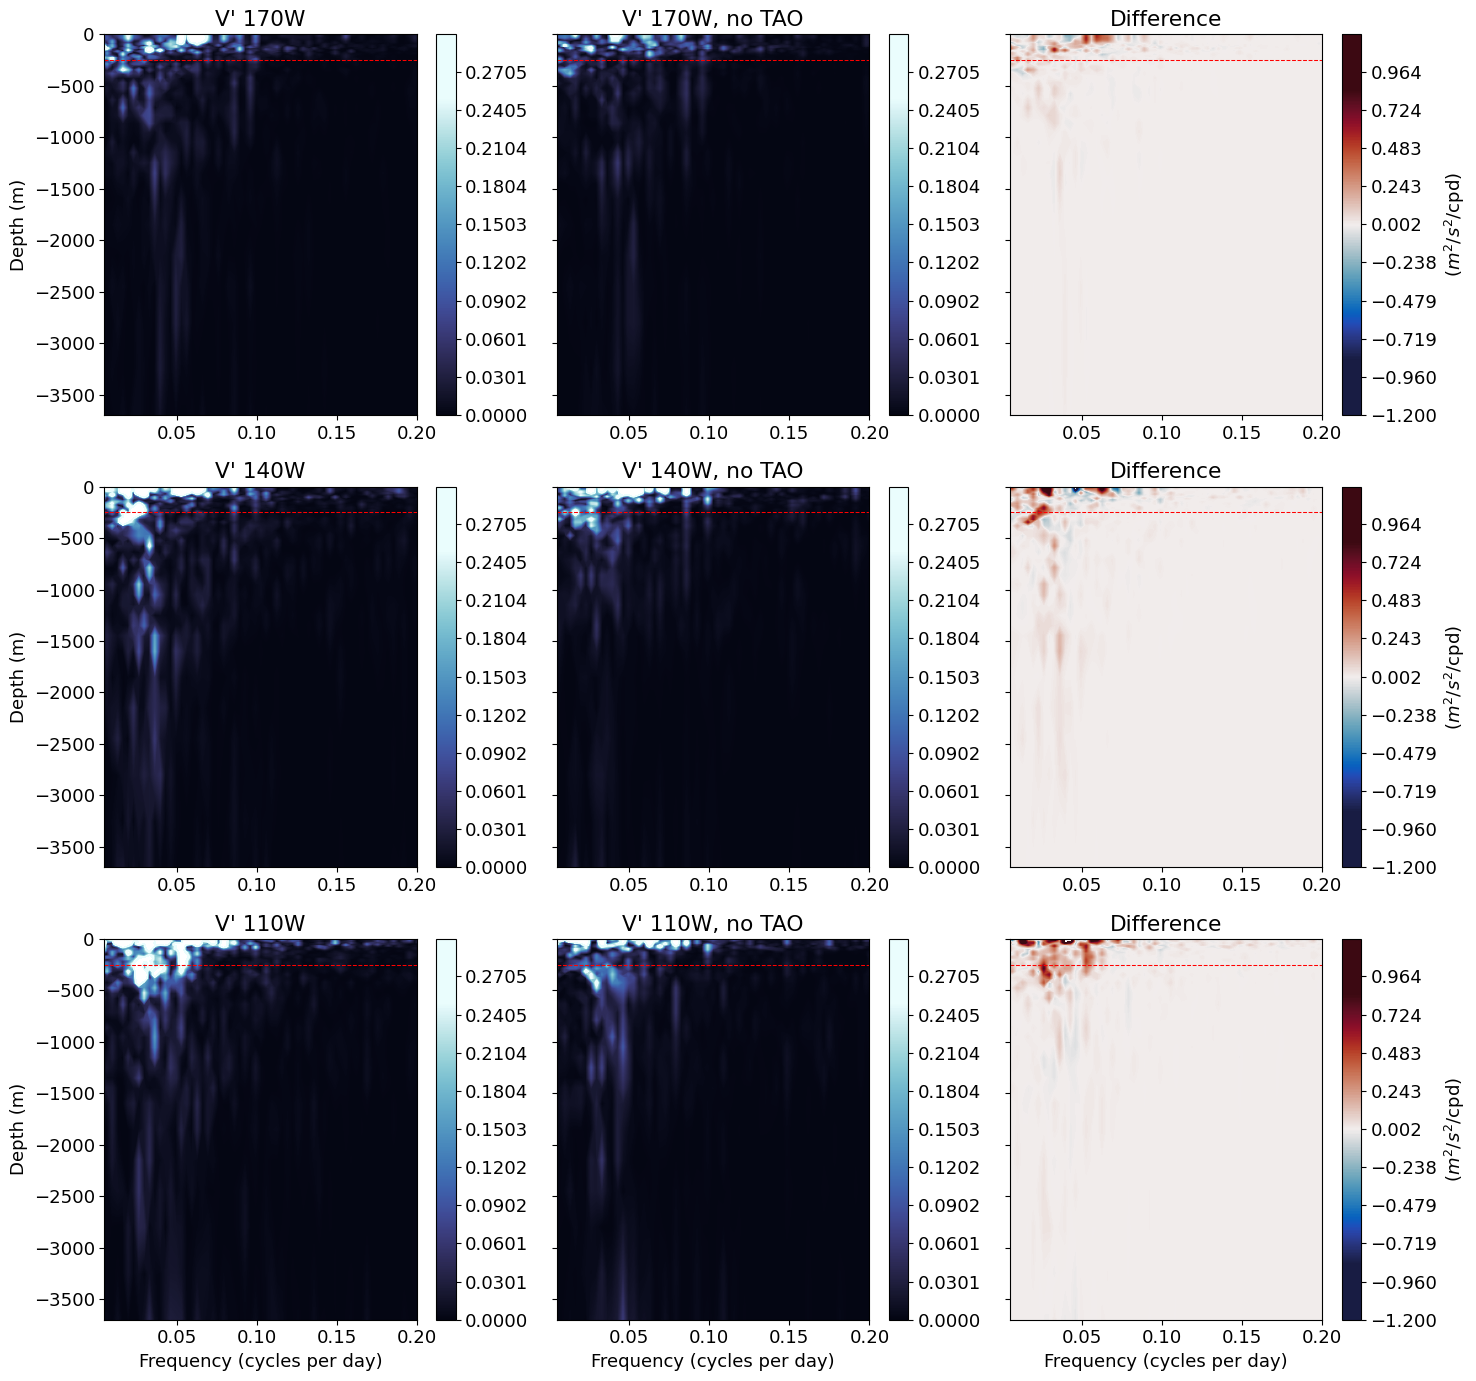

In [73]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3,sharey=True)
levels = np.linspace(0,0.3,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=190, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[0,0].set_title('V\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[0,1].set_title('V\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-1.2,1.2,500)
cf = ax[0,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, vmin=-0.85,vmax=0.85, cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('($m^2/s^2$/cpd)')

levels = np.linspace(0,0.3,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[1,0].set_title('V\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[1,1].set_title('V\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-1.2,1.2,500)
cf = ax[1,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, vmin=-0.85,vmax=0.85, cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('($m^2/s^2$/cpd)')

levels = np.linspace(0,0.3,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=250, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[2,0].set_title('V\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[2,1].set_title('V\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-1.2,1.2,500)
cf = ax[2,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, vmin=-0.85,vmax=0.85, cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('($m^2/s^2$/cpd)')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(0.005,0.2)

plt.tight_layout()
fig.savefig(foldername + 'V_spectrum_v_depth_9Panel.png',dpi=300)

In [74]:
from matplotlib.colors import SymLogNorm

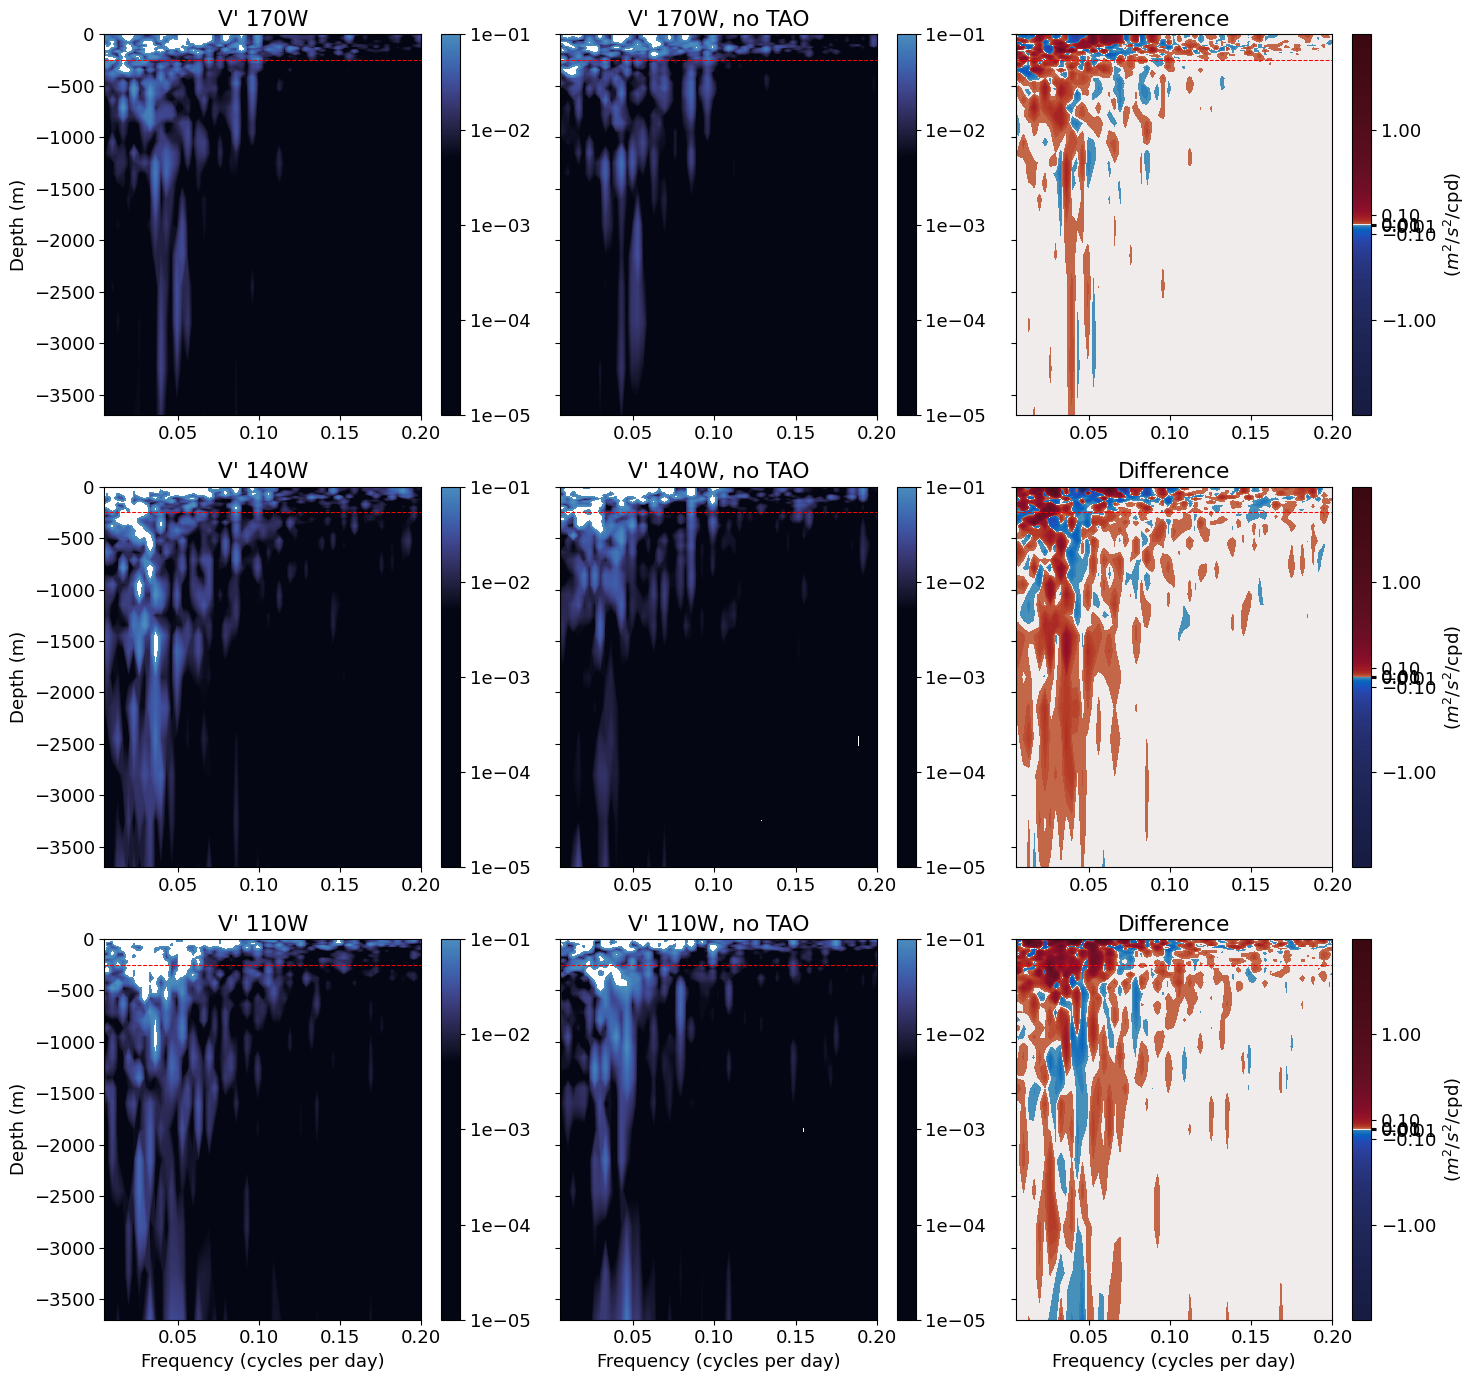

In [75]:
ticks = [
    -1, -1e-1, -1e-2,
     0,
     1e-2, 1e-1, 1
]

fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3,sharey=True)
log_levels = np.logspace(-5,-1,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=190, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=log_levels, norm=LogNorm(vmin=5e-3,vmax=1e0), cmap=cmo.ice)
ax[0,0].set_title('V\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=log_levels, norm=LogNorm(vmin=5e-3,vmax=1e0), cmap=cmo.ice)
ax[0,1].set_title('V\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('')

sym_log_levels = np.linspace(-2,2,500)
cf = ax[0,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=sym_log_levels, norm=SymLogNorm(linthresh=1e-3,linscale=1,vmin=-2e0,vmax=2e0), cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_ticks(ticks)
cbar.set_label('($m^2/s^2$/cpd)')

vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=log_levels, norm=LogNorm(vmin=5e-3,vmax=1e0), cmap=cmo.ice)
ax[1,0].set_title('V\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=log_levels, norm=LogNorm(vmin=5e-3,vmax=1e0), cmap=cmo.ice)
ax[1,1].set_title('V\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('')

cf = ax[1,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=sym_log_levels, norm=SymLogNorm(linthresh=1e-3,linscale=1,vmin=-2e0,vmax=2e0), cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_ticks(ticks)
cbar.set_label('($m^2/s^2$/cpd)')

vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=250, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=log_levels, norm=LogNorm(vmin=5e-3,vmax=1e0), cmap=cmo.ice)
ax[2,0].set_title('V\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=log_levels, norm=LogNorm(vmin=5e-3,vmax=1e0), cmap=cmo.ice)
ax[2,1].set_title('V\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatter(base=10)
cbar.set_label('')

cf = ax[2,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=sym_log_levels, norm=SymLogNorm(linthresh=1e-3,linscale=1,vmin=-2e0,vmax=2e0), cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_ticks(ticks)
cbar.set_label('($m^2/s^2$/cpd)')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(0.005,0.2)

plt.tight_layout()
fig.savefig(foldername + 'V_spectrum_v_depth_9Panel_logscale.png',dpi=300)

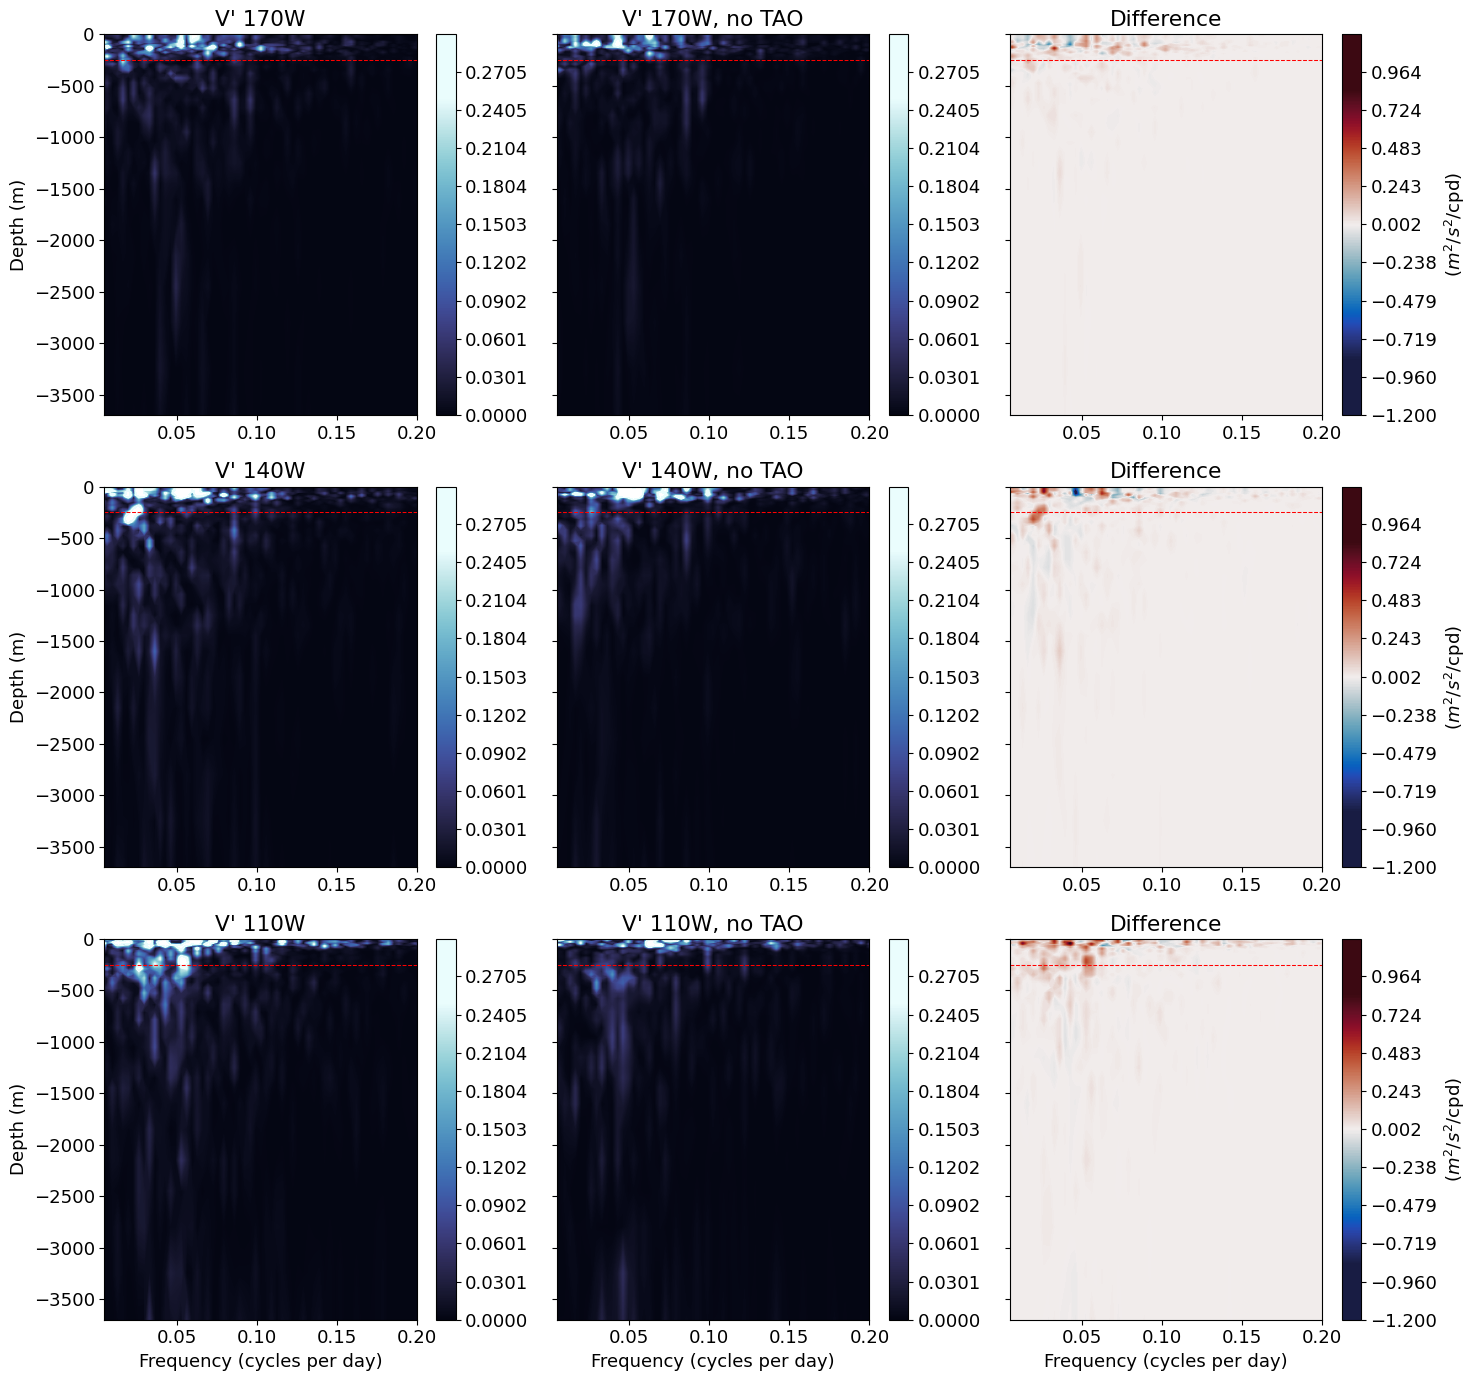

In [76]:
fig, ax = plt.subplots(figsize=(15,14),ncols=3,nrows=3,sharey=True)
levels = np.linspace(0,0.3,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=1.0, XC=190, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[0,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[0,0].set_title('V\' 170W')
ax[0,0].set_xlabel('')
ax[0,0].set_ylabel('Depth (m)')
ax[0,0].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,0])
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=1.0, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[0,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[0,1].set_title('V\' 170W, no TAO')
ax[0,1].set_xlabel('')
ax[0,1].set_ylabel('')
ax[0,1].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,1])
cbar.set_label('')

levels = np.linspace(-1.2,1.2,500)
cf = ax[0,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, vmin=-0.85,vmax=0.85, cmap=cmo.balance)
ax[0,2].set_title('Difference')
ax[0,2].set_xlabel('')
ax[0,2].set_ylabel('')
ax[0,2].set_ylim(-5100,0)
cbar = fig.colorbar(cf, ax=ax[0,2])
cbar.set_label('($m^2/s^2$/cpd)')

levels = np.linspace(0,0.3,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=1.0, XC=220, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[1,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[1,0].set_title('V\' 140W')
ax[1,0].set_xlabel('')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,0])
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=1.0, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[1,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[1,1].set_title('V\' 140W, no TAO')
ax[1,1].set_xlabel('')
ax[1,1].set_ylabel('')
ax[1,1].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,1])
cbar.set_label('')

levels = np.linspace(-1.2,1.2,500)
cf = ax[1,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, vmin=-0.85,vmax=0.85, cmap=cmo.balance)
ax[1,2].set_title('Difference')
ax[1,2].set_xlabel('')
ax[1,2].set_ylabel('')
ax[1,2].set_ylim(-4100,0)
cbar = fig.colorbar(cf, ax=ax[1,2])
cbar.set_label('($m^2/s^2$/cpd)')

levels = np.linspace(0,0.3,500)
vvel = ds_tpose_TAO.VVEL.sel(YG=1.0, XC=250, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
psd = np.where(psd > 1e-10, psd, np.nan)
cf = ax[2,0].contourf(freq_cpd, ds_tpose_TAO.Z, psd.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[2,0].set_title('V\' 110W')
ax[2,0].set_xlabel('Frequency (cycles per day)')
ax[2,0].set_ylabel('Depth (m)')
ax[2,0].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,0])
cbar.set_label('')

vvel = ds_tpose_noTAO.VVEL.sel(YG=1.0, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)
psd_noTAO = np.where(psd_noTAO > 1e-10, psd_noTAO, np.nan)
cf = ax[2,1].contourf(freq_cpd, ds_tpose_TAO.Z, psd_noTAO.T, levels=levels, vmin=0.0,vmax=0.25, cmap=cmo.ice)
ax[2,1].set_title('V\' 110W, no TAO')
ax[2,1].set_xlabel('Frequency (cycles per day)')
ax[2,1].set_ylabel('')
ax[2,1].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,1])
cbar.set_label('')

levels = np.linspace(-1.2,1.2,500)
cf = ax[2,2].contourf(freq_cpd, ds_tpose_TAO.Z, (psd - psd_noTAO).T, levels=levels, vmin=-0.85,vmax=0.85, cmap=cmo.balance)
ax[2,2].set_title('Difference')
ax[2,2].set_xlabel('Frequency (cycles per day)')
ax[2,2].set_ylabel('')
ax[2,2].set_ylim(-3700,0)
cbar = fig.colorbar(cf, ax=ax[2,2])
cbar.set_label('($m^2/s^2$/cpd)')

for ax in ax.flatten():
    ax.axhline(-250,color='r',ls='--',lw=0.75)
    ax.set_xlim(0.005,0.2)

plt.tight_layout()
fig.savefig(foldername + 'V_spectrum_v_depth_9Panel_1N.png',dpi=300)

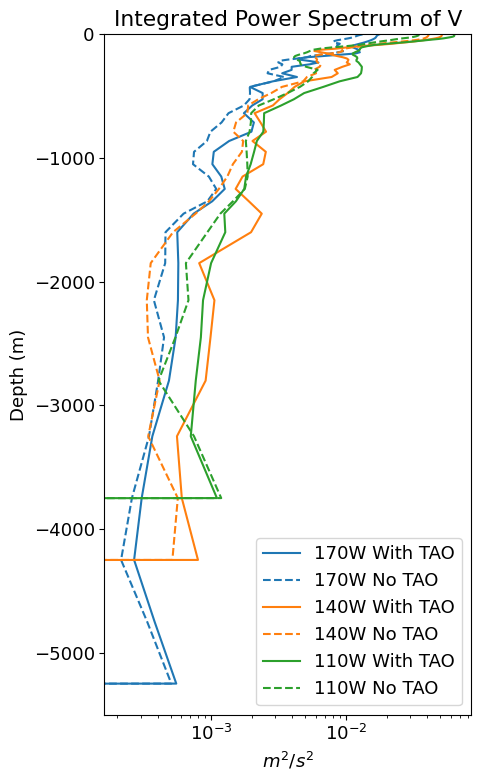

In [80]:
vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=190, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=190, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)

integrated_psd = np.trapezoid(psd, x=freq_cpd, axis=0)
integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_cpd, axis=0)

fig, ax = plt.subplots(figsize=(5,8))
ax.plot(integrated_psd, ds_tpose_TAO.Z, color='tab:blue', lw=1.5, label='170W With TAO')
ax.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color='tab:blue', ls='--', lw=1.5,  label='170W No TAO')

vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=220, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)

integrated_psd = np.trapezoid(psd, x=freq_cpd, axis=0)
integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_cpd, axis=0)

ax.plot(integrated_psd, ds_tpose_TAO.Z, color='tab:orange', lw=1.5, label='140W With TAO')
ax.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color='tab:orange', ls='--', lw=1.5,  label='140W No TAO')

vvel = ds_tpose_TAO.VVEL.sel(YG=0.0, XC=250, method='nearest')
_, _, psd, _, freq_cpd = psd_for_plot(vvel)
vvel = ds_tpose_noTAO.VVEL.sel(YG=0.0, XC=250, method='nearest')
_, _, psd_noTAO, _, freq_cpd = psd_for_plot(vvel)

integrated_psd = np.trapezoid(psd, x=freq_cpd, axis=0)
integrated_psd_noTAO = np.trapezoid(psd_noTAO, x=freq_cpd, axis=0)

ax.plot(integrated_psd, ds_tpose_TAO.Z, color='tab:green', lw=1.5, label='110W With TAO')
ax.plot(integrated_psd_noTAO, ds_tpose_TAO.Z, color='tab:green', ls='--', lw=1.5,  label='110W No TAO')

ax.set_xlabel('$m^2/s^2$')
ax.set_ylabel('Depth (m)')
ax.set_title('Integrated Power Spectrum of V')
ax.semilogx()
ax.legend()
ax.set_ylim(-5500,0)

plt.tight_layout()
fig.savefig(foldername + 'V_PSD_integrated.png',dpi=300)

In [78]:
client.shutdown()
cluster.close()
client.close()